In [1]:
import json
import re
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud
from collections import Counter
from collections import defaultdict
import numpy as np
import nltk
from nltk.corpus import stopwords
from pathlib import Path


In [2]:
data_folder = "/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe"
json_files = glob(f"{data_folder}/*/description_videos_*.json")
print(len(json_files), "JSON files found.")

6319 JSON files found.


In [3]:
import re
from pathlib import Path
import json
import pandas as pd


def extract_block_items_loose(block_text):
    """Extrait tout ce qui est après <ID> jusqu'à la fin du bloc ou le prochain <ID>."""
    if not block_text:
        return []
    # On split sur <ID> et on récupère le texte jusqu'au prochain <ID> ou fin de bloc
    items = re.split(r"<\d+>", block_text)[
        1:
    ]  # le premier split est avant le premier <ID>
    return [
        m.strip().split("<")[0] for m in items
    ]  # on coupe au premier < pour éviter les balises mal fermées


rows = []

for json_path in json_files:
    video_id = Path(json_path).stem.replace("description_videos_", "")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.search(r"(\d+)$", scene_key)  # dernier chiffre du path
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        # Extraire les blocs de BodyDesc, Style et Action
        body_items = extract_block_items_loose(
            re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL).group(1)
            if re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
            else None
        )
        style_items = extract_block_items_loose(
            re.search(r"<Style>(.*?)</Style>", content, re.DOTALL).group(1)
            if re.search(r"<Style>(.*?)</Style>", content, re.DOTALL)
            else None
        )
        action_items = extract_block_items_loose(
            re.search(r"<Action>(.*?)</Action>", content, re.DOTALL).group(1)
            if re.search(r"<Action>(.*?)</Action>", content, re.DOTALL)
            else None
        )

        # Créer les lignes par position
        max_len = max(len(body_items), len(style_items), len(action_items))
        for i in range(max_len):
            rows.append(
                {
                    "video_id": video_id,
                    "scene_id": scene_id,
                    "person_id": str(i),
                    "body_desc": body_items[i] if i < len(body_items) else None,
                    "style": style_items[i] if i < len(style_items) else None,
                    "action": action_items[i] if i < len(action_items) else None,
                }
            )

df = pd.DataFrame(rows)
print(df.head(10))
print(f"Total sequences: {len(df)}")

      video_id scene_id person_id  \
0  video_20084        2         0   
1  video_20084        2         1   
2  video_20084        2         2   
3  video_20084        5         0   
4  video_20084        5         1   
5  video_20084        1         0   
6  video_20084        1         1   
7  video_20084        4         0   
8  video_20084        4         1   
9  video_20084        3         0   

                                           body_desc  \
0       Bent at the waist, arms moving rhythmically.   
1  Standing, knees slightly bent, holding sheep’s...   
2                 Bent forward, focused on shearing.   
3  Bent over, arms moving rhythmically, focused o...   
4  Bent over, hands maneuvering clippers, body sl...   
5  Standing upright, leaning slightly forward, ar...   
6  Bent at the waist, knees slightly bent, focuse...   
7  Bent at the waist, arms moving rhythmically ov...   
8  Bent at the waist, hands guiding clippers alon...   
9  Bent forward, arms moving rhy

In [4]:
scene_movements = []
bodydesc_texts = []
scenedesc_texts = []

for json_path in json_files:
    match_vid = re.search(r"video_(\d+)", json_path)
    if not match_vid:
        continue
    video_id = match_vid.group(1)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.search(r"(\d+)$", scene_key)
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        body_block = re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
        scene_desc = re.search(r"<SceneDesc>(.*?)</SceneDesc>", content, re.DOTALL)

        # compter mouvements robustement
        body_count = 0
        if body_block:
            body_count = len(
                re.findall(r"<[^>]+>.*?</[^>]+>", body_block.group(1), re.DOTALL)
            )

        scene_movements.append(
            {"video_id": video_id, "scene_id": scene_id, "movement_count": body_count}
        )

        if body_block:
            bodydesc_texts.append(body_block.group(1).strip())
        if scene_desc:
            scenedesc_texts.append(scene_desc.group(1).strip())

df_movements = pd.DataFrame(scene_movements)
print(df_movements.head(10))

  video_id scene_id  movement_count
0    20084        2               3
1    20084        5               2
2    20084        1               2
3    20084        4               2
4    20084        3               3
5    20084        6               3
6    20084        7               3
7    11688        2               0
8    11688        1               1
9     8778        1               1


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/natsalaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


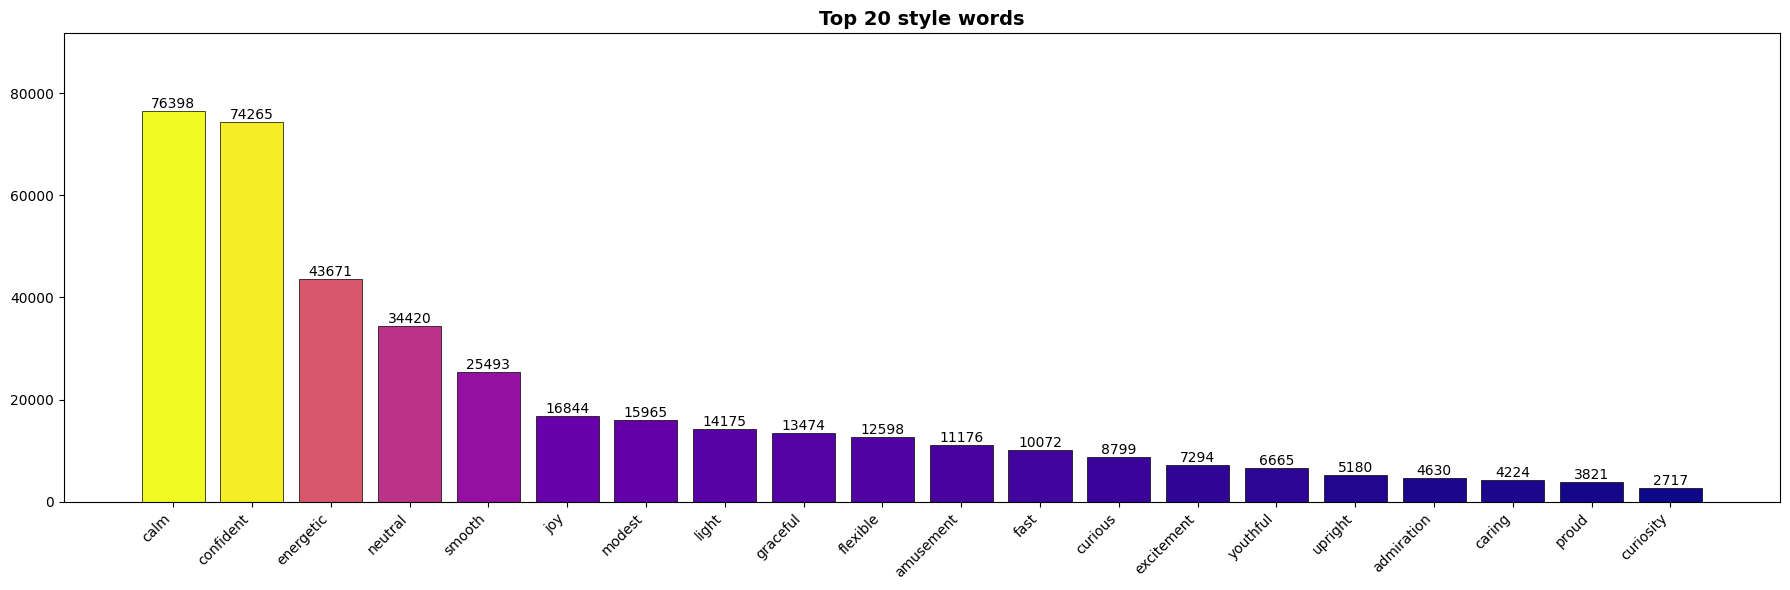

In [5]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def extract_words(text):
    if not text:  # skip None or empty string
        return []
    return [
        w
        for w in re.findall(r"\b\w+\b", text.lower())
        if w not in stop_words and len(w) > 1
    ]


# Collect style words safely
style_words = []
for style in df["style"]:
    style_words.extend(extract_words(style))

# Continue comme avant
from collections import Counter

if style_words:
    style_counts = Counter(style_words).most_common(20)
    style_labels, style_vals = zip(*style_counts)

    fig, ax = plt.subplots(1, 1, figsize=(18, 6))
    plt.style.use("ggplot")

    def plot_pretty_bar(ax, labels, values, title, cmap_name="viridis"):
        import matplotlib.colors as mcolors

        cmap = plt.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
        colors = [cmap(norm(val)) for val in values]
        x = range(len(labels))
        bars = ax.bar(x, values, color=colors, edgecolor="black")
        ax.set_title(title, fontsize=14, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                str(height),
                ha="center",
                va="bottom",
                fontsize=10,
            )
        ax.set_ylim(0, max(values) * 1.2)

    plot_pretty_bar(
        ax, style_labels, style_vals, "Top 20 style words", cmap_name="plasma"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No style words found in the DataFrame.")

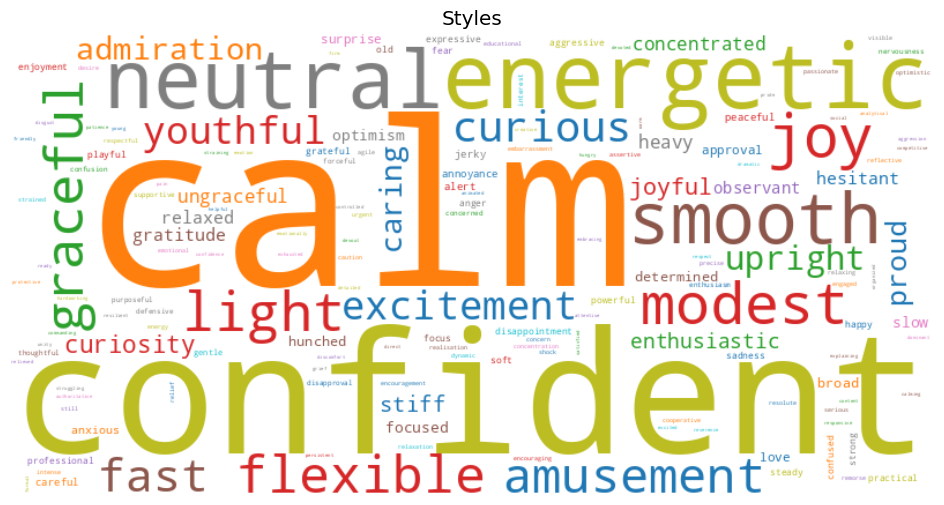

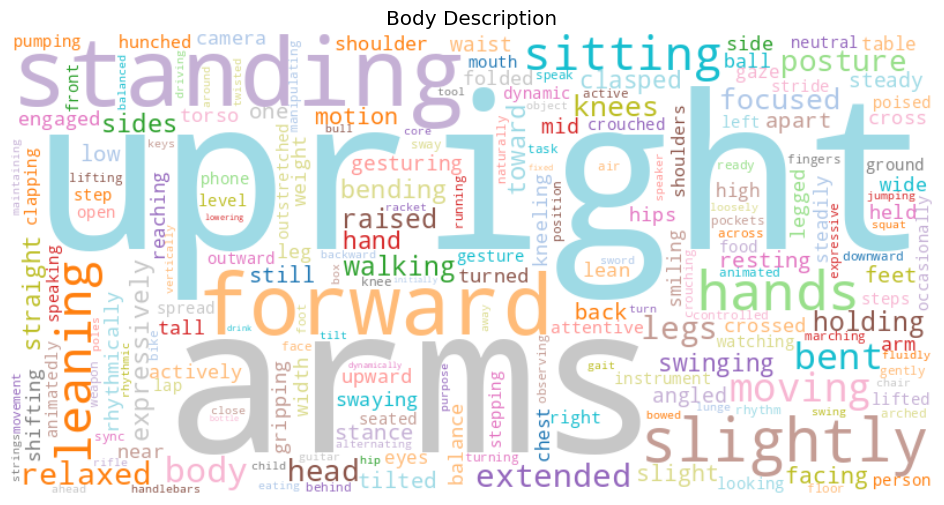

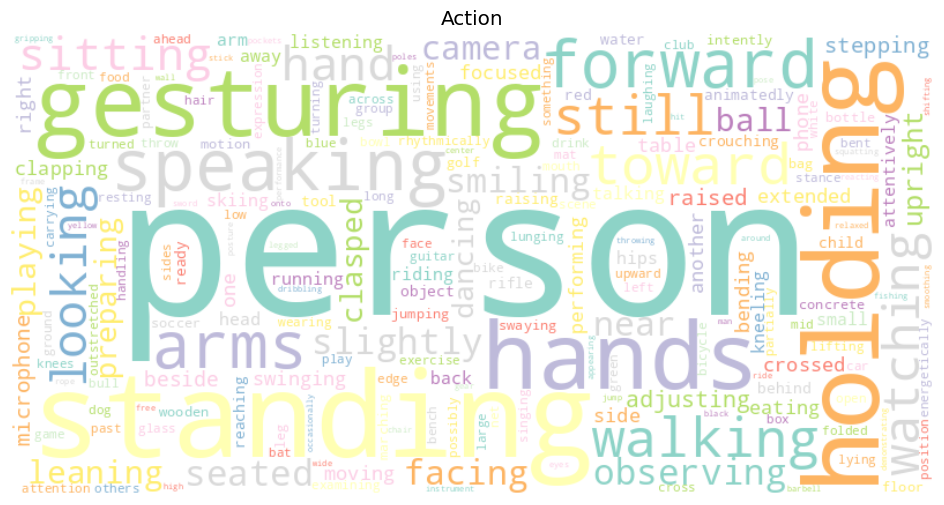

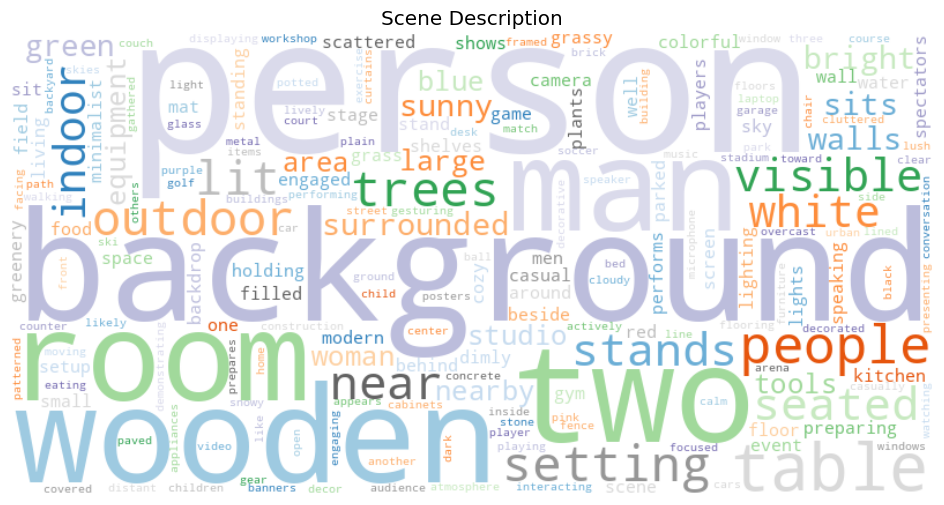

In [6]:
def extract_inner_bodydesc_texts(raw_list):
    """
    Extrait les textes internes de chaque BodyDesc,
    même si les balises sont de type <0>...</0>, <1>...</1>, etc.
    """
    texts = []
    for raw in raw_list:
        if raw:
            # attrape tout ce qui est entre <id>...</id>
            texts.extend(
                [m.strip() for m in re.findall(r"<\d+>(.*?)</\d+>", raw, re.DOTALL)]
            )
    return texts


if "df" in locals() and "bodydesc_texts" in locals() and "scenedesc_texts" in locals():
    def show_wc(word_list, title, cmap):
        wc = WordCloud(width=800, height=400, background_color="white", colormap=cmap)
        wc.generate_from_frequencies(Counter(word_list))
        plt.figure(figsize=(14, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

    style_words = [w for s in df["style"] for w in extract_words(s)] if "style" in df.columns else []
    if style_words:
        style_words = [w for s in df["style"] for w in extract_words(s)]
    body_words = [
        w
        for t in extract_inner_bodydesc_texts(bodydesc_texts)
        for w in extract_words(t)
    ]
    scene_words = [w for t in scenedesc_texts for w in extract_words(t)]

    action_words = (
        [w for a in df["action"] for w in extract_words(a)]
        if "action" in df.columns
        else []
    )
    if action_words:
        action_words = [w for a in df["action"] for w in extract_words(a)]
    show_wc(style_words, "Styles", "tab10")
    show_wc(body_words, "Body Description", "tab20")
    show_wc(action_words, "Action", "Set3")
    show_wc(scene_words, "Scene Description", "tab20c")
else:
    print("Missing datafarme or description lists.")

--- Persons per scene ---
Total person sequences: 172182
Mean: 1.87
Median: 1.00
Q1: 1.00
Q3: 2.00

--- Scenes per video ---
Total scenes: 92182
Mean: 14.61
Median: 5.00
Q1: 2.00
Q3: 15.00


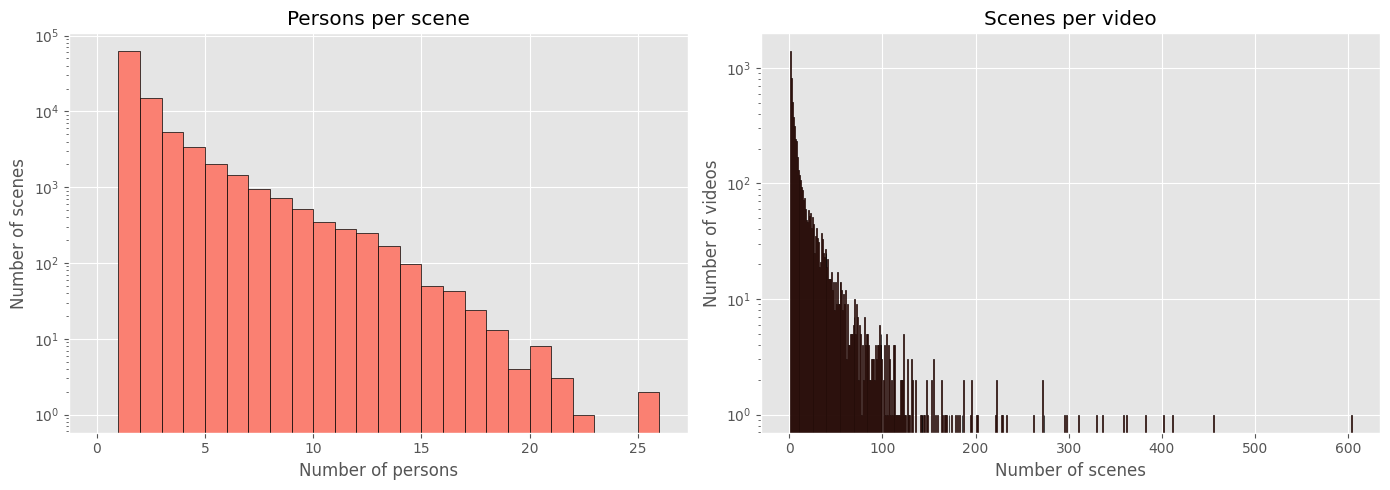

In [7]:
if "df" in locals():

    persons_per_scene = df.groupby(["video_id", "scene_id"])["person_id"].nunique()
    scenes_per_video = df.groupby("video_id")["scene_id"].nunique()

    print("--- Persons per scene ---")
    print(f"Total person sequences: {persons_per_scene.sum()}")
    print(f"Mean: {persons_per_scene.mean():.2f}")
    print(f"Median: {persons_per_scene.median():.2f}")
    print(f"Q1: {persons_per_scene.quantile(0.25):.2f}")
    print(f"Q3: {persons_per_scene.quantile(0.75):.2f}")

    print("\n--- Scenes per video ---")
    print(f"Total scenes: {scenes_per_video.sum()}")
    print(f"Mean: {scenes_per_video.mean():.2f}")
    print(f"Median: {scenes_per_video.median():.2f}")
    print(f"Q1: {scenes_per_video.quantile(0.25):.2f}")
    print(f"Q3: {scenes_per_video.quantile(0.75):.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        persons_per_scene,
        bins=range(0, persons_per_scene.max() + 2),
        facecolor="salmon",
        edgecolor="black",
    )
    axes[0].set_title("Persons per scene")
    axes[0].set_xlabel("Number of persons")
    axes[0].set_ylabel("Number of scenes")
    axes[0].set_yscale("log")

    axes[1].hist(
        scenes_per_video,
        bins=range(0, scenes_per_video.max() + 2),
        edgecolor="black",
    )
    axes[1].set_title("Scenes per video")
    axes[1].set_xlabel("Number of scenes")
    axes[1].set_ylabel("Number of videos")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()
else:
    print("DataFrame `df` is not defined.")

In [8]:
print(persons_per_scene)
print(persons_per_scene.sum())
print((persons_per_scene>=2).sum())

video_id     scene_id
video_10000  1           1
             2           1
video_10001  1           1
             10          1
             11          1
                        ..
video_9999   5           1
             6           1
             7           1
             8           1
             9           1
Name: person_id, Length: 92182, dtype: int64
172182
30563


In [9]:
import os
import json
import pandas as pd

rows = []

# Walk through current directory
for root, dirs, files in os.walk(
    "/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe"
):
    for f in files:
        if f.endswith(".json"):
            path = os.path.join(root, f)
            try:
                with open(path, "r") as fp:
                    data = json.load(fp)
                # Count elements: for dict = len(keys), for list = len(list), else 1
                if isinstance(data, dict):
                    count = len(data)
                elif isinstance(data, list):
                    count = len(data)
                else:
                    count = 1
            except Exception as e:
                count = None
            rows.append({"file": path, "num_elements": count})
print(rows)
df = pd.DataFrame(rows)
print(df)

[{'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_20084/description_videos_video_20084.json', 'num_elements': 7}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_11688/description_videos_video_11688.json', 'num_elements': 2}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_8778/description_videos_video_8778.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_12705/description_videos_video_12705.json', 'num_elements': 12}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_19605/description_videos_video_19605.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_16873/description_videos_video_16873.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_14642/description_videos_video_14642.json', 'num_elements': 12}, {'file': '/home/natsalaz/D

In [10]:
print(df["file"].count())
print(df["num_elements"].sum())

6319
92864


In [11]:
second_max_idx = scenes_per_video.nlargest(2).index[1]
print(f"Index 2e max : {second_max_idx}")
print(f"Valeur      : {scenes_per_video.loc[second_max_idx]}")

Index 2e max : video_19332
Valeur      : 455


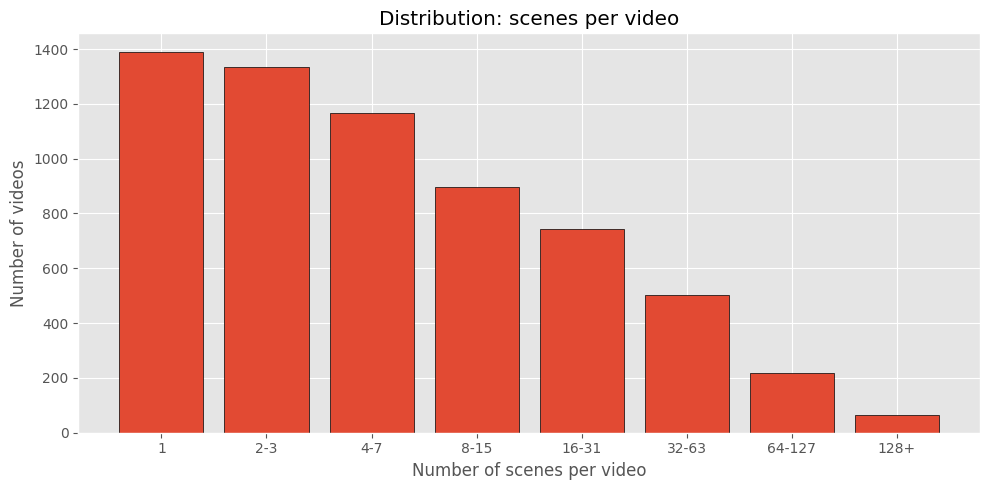

In [12]:
custom_bins = [0, 1, 3, 7, 15, 31, 63, 127, np.inf]
custom_labels = ["1", "2-3", "4-7", "8-15", "16-31", "32-63", "64-127", "128+"]

scenes_per_video_binned = pd.cut(
    scenes_per_video, bins=custom_bins, labels=custom_labels, right=True
)

scene_bin_counts = scenes_per_video_binned.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scene_bin_counts.index.astype(str), scene_bin_counts.values, edgecolor="black")
ax.set_title("Distribution: scenes per video")
ax.set_xlabel("Number of scenes per video")
ax.set_ylabel("Number of videos")
plt.tight_layout()
plt.show()

In [13]:
from glob import glob
import numpy as np
import os

poses_files = glob(f"{data_folder}/*/*.npz")
total_frames = 0
total_face_frames = 0
bad_files = []
person_count_per_file = {}

for path in poses_files:
    try:
        data = np.load(path, allow_pickle=True)
        person_keys = [key for key in data.files if key.startswith("body_")]
        num_persons = 0
        frames_in_file = 0
        face_frames_in_file = 0
        for key in person_keys:
            body = data[key].item()
            if "poses" in body and hasattr(body["poses"], "shape"):
                n = body["poses"].shape[0]
                frames_in_file += n
                total_frames += n
                num_persons += 1
                face_n = np.sum(np.mean(np.abs(np.array(body["expressions"])), axis=1) > 1e-6)
                face_frames_in_file += face_n
                total_face_frames += face_n
        person_count_per_file[os.path.basename(path)] = {
            "num_persons": num_persons,
            "total_frames": frames_in_file,
            "face_frames": face_frames_in_file,
        }

    except Exception as e:
        bad_files.append((os.path.basename(path), str(e)))

# Résumé
print(f"\nFichiers traités : {len(person_count_per_file)}")
print(f"Total 3D pose frames: {total_frames:,}")

# Exemples
print("\nNombre de personnes + frames (exemples) :")
for fname, stats in list(person_count_per_file.items())[:10]:
    print(f"{fname}: {stats['num_persons']} personnes, {stats['total_frames']} frames, {stats['face_frames']} frames avec visage")

if bad_files:
    print(f"\nFichiers invalides : {len(bad_files)}")
    for name, err in bad_files[:5]:
        print(f" - {name}: {err}")


Fichiers traités : 95754
Total 3D pose frames: 33,768,084

Nombre de personnes + frames (exemples) :
video_20084_merged_scene_6.npz: 3 personnes, 363 frames, 0 frames avec visage
video_20084_merged_scene_1.npz: 2 personnes, 142 frames, 0 frames avec visage
video_20084_merged_scene_5.npz: 2 personnes, 242 frames, 0 frames avec visage
video_20084_merged_scene_2.npz: 3 personnes, 237 frames, 0 frames avec visage
video_20084_merged_scene_7.npz: 3 personnes, 585 frames, 0 frames avec visage
video_20084_merged_scene_4.npz: 2 personnes, 286 frames, 0 frames avec visage
video_20084_merged_scene_3.npz: 3 personnes, 213 frames, 0 frames avec visage
video_11688_merged_scene_2.npz: 1 personnes, 70 frames, 0 frames avec visage
video_11688_merged_scene_1.npz: 1 personnes, 86 frames, 86 frames avec visage
video_8778_merged_scene_1.npz: 1 personnes, 125 frames, 83 frames avec visage


In [14]:
total_persons = persons_per_scene.sum()
total_scenes = persons_per_scene.index.nunique()
total_videos = scenes_per_video.index.nunique()

print(
    f"{total_persons:,} sequences and person annotations across {total_scenes:,} scenes, taken from {total_videos:,} YouTube CC videos"
    f", covering {total_frames:,} 3D poses, covering {total_face_frames:,} 3D expressions ({round(total_face_frames/total_frames*100,2)}% of all frames),"
    f"each annotated with structured descriptions of body movement, "
    f"emotion, style, and scene context."
)

172,182 sequences and person annotations across 92,182 scenes, taken from 6,309 YouTube CC videos, covering 33,768,084 3D poses, covering 16,736,574 3D expressions (49.56% of all frames),each annotated with structured descriptions of body movement, emotion, style, and scene context.


In [15]:
print(
    round(total_frames / 30, 2),
    "s",
    round(total_frames / (60 * 30), 2),
    "min",
    round(total_frames / (3600 * 30), 2),
    "h",
)

1125602.8 s 18760.05 min 312.67 h


In [16]:
print(df)
df_ids = df_movements.groupby(["video_id"])

                                                   file  num_elements
0     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             7
1     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
2     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
3     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            12
4     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
...                                                 ...           ...
6314  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
6315  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
6316  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            10
6317  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
6318  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            16

[6319 rows x 2 columns]


In [17]:
total_frames = 0
total_face_frames = 0
bad_files = []
person_count_per_file = {}

for path in poses_files:
    try:
        data = np.load(path, allow_pickle=True)
        person_keys = [key for key in data.files if key.startswith("body_")]

        num_persons = 0
        max_frames_in_file = 0
        max_face_frames_in_file = 0

        for key in person_keys:
            body = data[key].item()
            if "poses" in body and hasattr(body["poses"], "shape"):
                n = body["poses"].shape[0]
                max_frames_in_file = max(max_frames_in_file, n)

                face_n = np.sum(
                    np.mean(np.abs(np.array(body["expressions"])), axis=1) > 1e-6
                )
                max_face_frames_in_file = max(max_face_frames_in_file, face_n)

                num_persons += 1

        total_frames += max_frames_in_file
        total_face_frames += max_face_frames_in_file

        person_count_per_file[os.path.basename(path)] = {
            "num_persons": num_persons,
            "scene_frames": max_frames_in_file,
            "face_frames": max_face_frames_in_file,
        }

    except Exception as e:
        bad_files.append((os.path.basename(path), str(e)))

In [18]:
print(f"\nFichiers traités : {len(person_count_per_file)}")
print(f"Total frames scènes (max par fichier) : {total_frames:,}")

print("\nScènes (exemples) :")
for fname, stats in list(person_count_per_file.items())[:10]:
    print(
        f"{fname}: {stats['num_persons']} personnes, "
        f"{stats['scene_frames']} frames scène, "
        f"{stats['face_frames']} frames visage"
    )


Fichiers traités : 95754
Total frames scènes (max par fichier) : 19,223,932

Scènes (exemples) :
video_20084_merged_scene_6.npz: 3 personnes, 121 frames scène, 0 frames visage
video_20084_merged_scene_1.npz: 2 personnes, 71 frames scène, 0 frames visage
video_20084_merged_scene_5.npz: 2 personnes, 121 frames scène, 0 frames visage
video_20084_merged_scene_2.npz: 3 personnes, 79 frames scène, 0 frames visage
video_20084_merged_scene_7.npz: 3 personnes, 195 frames scène, 0 frames visage
video_20084_merged_scene_4.npz: 2 personnes, 143 frames scène, 0 frames visage
video_20084_merged_scene_3.npz: 3 personnes, 71 frames scène, 0 frames visage
video_11688_merged_scene_2.npz: 1 personnes, 70 frames scène, 0 frames visage
video_11688_merged_scene_1.npz: 1 personnes, 86 frames scène, 86 frames visage
video_8778_merged_scene_1.npz: 1 personnes, 125 frames scène, 83 frames visage


In [19]:
print(total_frames)
print(total_frames/30)
print(total_frames/30/60)
print(total_frames/30/3600)

19223932
640797.7333333333
10679.96222222222
177.99937037037034


In [20]:
print(total_face_frames)

12455794
